# Lecture 2 — Class Exercise
# Bar Charts: World Happiness Report 2023

---

> **Your task:** Create **2 polished bar charts** using the World Happiness Report dataset.  
> **Push to:** `week02/lecture02_exercise.ipynb` in **your own GitHub repo** before the end of class.

---

### Rules (these will be checked in the model answer review next week)
1. Every bar chart **must have a zero baseline** — no exceptions (SWD p.51)
2. Every chart **must have an insight title**, not a topic title (SWD p.29)
3. Aim for **professional quality** — clean background, readable font, no clutter
4. Horizontal bars for long category names (SWD p.57)

---


## Setup — Run this cell first


In [2]:
import pandas as pd
import numpy as np

# World Happiness Report 2023 — representative data
# Source: https://www.kaggle.com/datasets/ajaypalsinghlo/world-happiness-report-2023

df = pd.read_csv('../data/world_happiness_2023.csv')
df.columns = ['Country','Region','Happiness_Score','GDP','Social_Support',
              'Life_Expectancy','Freedom','Generosity','Corruption']


print(f"Dataset: {len(df)} countries, {len(df.columns)} columns")
print(df.head())


Dataset: 63 countries, 9 columns
       Country                        Region  Happiness_Score     GDP  \
0      Finland                Western Europe            7.804  10.775   
1      Denmark                Western Europe            7.586  10.933   
2      Iceland                Western Europe            7.525  10.878   
3       Israel  Middle East and North Africa            7.473  10.527   
4  Netherlands                Western Europe            7.464  11.015   

   Social_Support  Life_Expectancy  Freedom  Generosity  Corruption  
0           0.954             71.9    0.949       0.142       0.179  
1           0.954             72.7    0.931       0.168       0.234  
2           0.983             72.5    0.961       0.260       0.150  
3           0.916             72.4    0.903       0.149       0.826  
4           0.939             72.4    0.879       0.240       0.296  


In [3]:
import plotly.express as px
import plotly.graph_objects as go

# Explore the dataset before you start
print("Regions in dataset:")
print(df['Region'].value_counts())
print("\nScore range:", df['Happiness_Score'].min(), "–", df['Happiness_Score'].max())
print("\nBottom 10 countries:")
print(df.nsmallest(10, 'Happiness_Score')[['Country','Region','Happiness_Score']])


Regions in dataset:
Region
Western Europe                  15
Latin America and Caribbean     13
Central and Eastern Europe       7
Sub-Saharan Africa               7
Middle East and North Africa     6
North America and ANZ            4
Southeast Asia                   4
South Asia                       4
East Asia                        3
Name: count, dtype: int64

Score range: 1.859 – 7.804

Bottom 10 countries:
        Country                        Region  Happiness_Score
60  Afghanistan                    South Asia            1.859
61      Lebanon  Middle East and North Africa            2.392
62     Zimbabwe            Sub-Saharan Africa            2.995
52     Ethiopia            Sub-Saharan Africa            3.564
53     Tanzania            Sub-Saharan Africa            3.698
48   Bangladesh                    South Asia            3.892
47        India                    South Asia            4.036
50        Kenya            Sub-Saharan Africa            4.112
54       Uganda

---
## Task 1 — Regional Comparison Bar Chart

**What to build:** A horizontal bar chart showing the **average happiness score by region**, sorted from highest to lowest.

**Requirements:**
- Horizontal orientation (category names are long)
- Sorted by score, descending (so the happiest region is at the top)
- Zero baseline on x-axis
- At least one design choice that goes beyond the Plotly default (colour, annotation, labels, etc.)
- An insight title that answers: *which region stands out and why does it matter?*

**Hint:** Use `df.groupby('Region')['Happiness_Score'].mean()` to compute the averages.


                         Region  Happiness_Score
5                    South Asia         3.618250
7            Sub-Saharan Africa         4.064714
3  Middle East and North Africa         4.943333
6                Southeast Asia         5.695250
2   Latin America and Caribbean         5.699000
1                     East Asia         5.966000
0    Central and Eastern Europe         6.338143
4         North America and ANZ         7.018250
8                Western Europe         7.085533


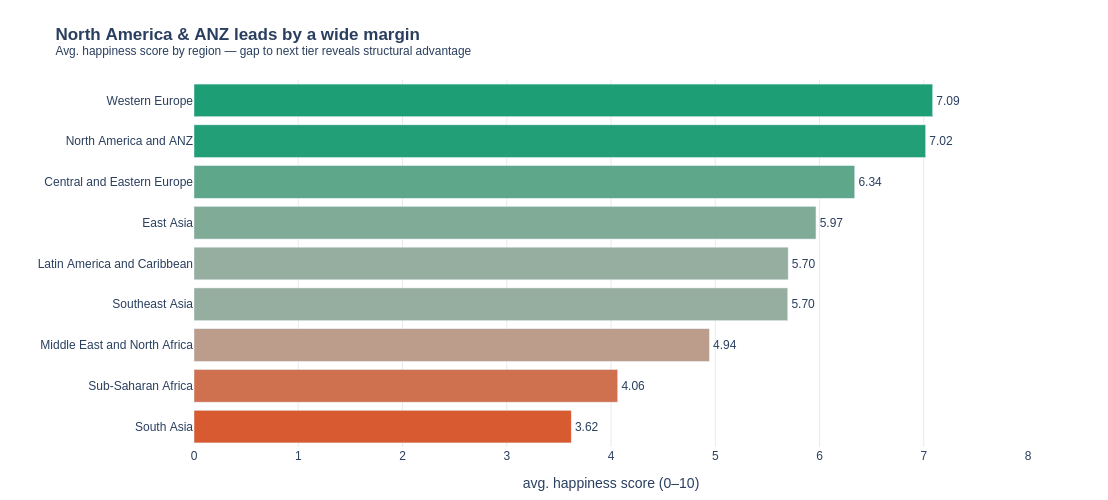

In [4]:
# Task 1: Regional comparison bar chart
# -------------------------------------

# Step 1: Compute average happiness score by region
region_avg = (df.groupby('Region')['Happiness_Score']
              .mean()
              .reset_index()
              .sort_values('Happiness_Score'))  # sort for horizontal bar

print(region_avg)

# Step 2: Build the chart
fig = px.bar(
    region_avg,
    x='Happiness_Score',
    y='Region',
    orientation='h',
    title='<b>North America & ANZ leads by a wide margin</b><br>'
          '<sup>Avg. happiness score by region — gap to next tier reveals structural advantage</sup>',
    color='Happiness_Score',
    color_continuous_scale=[
        (0.0, '#D85A30'),   # coral – low
        (0.5, '#B4B2A9'),   # gray  – mid
        (1.0, '#1D9E75'),   # teal  – high
    ],
    range_color=[region_avg['Happiness_Score'].min(),
                 region_avg['Happiness_Score'].max()],
    text='Happiness_Score',
)

fig.update_traces(
    texttemplate='%{text:.2f}',
    textposition='outside',
)

fig.update_layout(
    xaxis=dict(
        title='avg. happiness score (0–10)',
        range=[0, 8],           # zero baseline
        showgrid=True,
        gridcolor='rgba(200,200,200,0.4)',
    ),
    yaxis=dict(
        title='',
        categoryorder='total ascending',  # highest score at top
    ),
    coloraxis_showscale=False,
    plot_bgcolor='white',
    paper_bgcolor='white',
    margin=dict(l=20, r=80, t=80, b=40),
    height=500,
)

fig.show()



---
## Task 2 — Bottom vs. Top: A Contrast Story

**What to build:** A bar chart that highlights the **gap between the happiest and least happy countries**, focusing on a specific insight.

**Requirements:**
- Show the **top 8 AND bottom 8 countries** together (16 bars total)
- Use **colour** to distinguish the two groups (not Plotly's default rainbow)
- Add a **visual separator or annotation** that emphasises the gap
- Insight title that tells the story of the gap

**Hint:** Use `pd.concat([df.nlargest(8,'Happiness_Score'), df.nsmallest(8,'Happiness_Score')])` to get both groups.

**Stretch goal:** Add a vertical reference line showing the global average.


Global average: 5.81


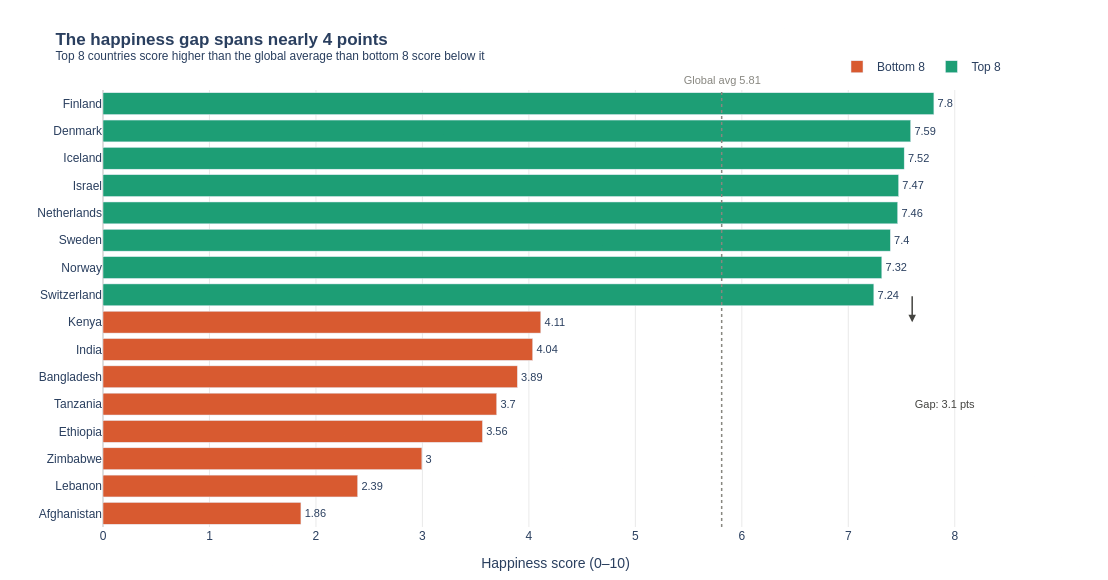

In [5]:
# Task 2: Top 8 vs. Bottom 8 contrast
# ------------------------------------

# Step 1: Get top and bottom countries
top8 = df.nlargest(8, 'Happiness_Score').copy()
top8['Group'] = 'Top 8'
bottom8 = df.nsmallest(8, 'Happiness_Score').copy()
bottom8['Group'] = 'Bottom 8'

combined = pd.concat([bottom8, top8]).sort_values('Happiness_Score')
global_avg = df['Happiness_Score'].mean()
print(f"Global average: {global_avg:.2f}")

# Step 2: Build the chart
fig = go.Figure()

colors = {'Top 8': '#1D9E75', 'Bottom 8': '#D85A30'}

for group in ['Bottom 8', 'Top 8']:
    mask = combined['Group'] == group
    fig.add_trace(go.Bar(
        x=combined.loc[mask, 'Happiness_Score'],
        y=combined.loc[mask, 'Country'],
        orientation='h',
        name=group,
        marker_color=colors[group],
        text=combined.loc[mask, 'Happiness_Score'].round(2),
        textposition='outside',
        textfont=dict(size=11),
    ))

# Global average reference line
fig.add_vline(
    x=global_avg,
    line_dash='dot',
    line_color='#888780',
    line_width=1.5,
    annotation_text=f'Global avg {global_avg:.2f}',
    annotation_position='top',
    annotation_font=dict(size=11, color='#888780'),
)

# Gap annotation — arrow spanning bottom to top anchor points
fig.add_annotation(
    x=7.6, y=bottom8['Country'].iloc[bottom8['Happiness_Score'].argmax()],
    ax=7.6, ay=top8['Country'].iloc[top8['Happiness_Score'].argmin()],
    xref='x', yref='y', axref='x', ayref='y',
    text='', showarrow=True,
    arrowhead=2, arrowwidth=1.5, arrowcolor='#444441',
)
fig.add_annotation(
    x=7.6,
    y=combined['Country'].iloc[len(bottom8) // 2],
    xref='x', yref='y',
    text=f"Gap: {top8['Happiness_Score'].min() - bottom8['Happiness_Score'].max():.1f} pts",
    showarrow=False,
    font=dict(size=11, color='#444441'),
    xanchor='left',
)

fig.update_layout(
    title=(
        '<b>The happiness gap spans nearly 4 points</b><br>'
        '<sup>Top 8 countries score higher than the global average than bottom 8 score below it</sup>'
    ),
    xaxis=dict(
        title='Happiness score (0–10)',
        range=[0, 8.5],
        showgrid=True,
        gridcolor='rgba(200,200,200,0.4)',
        zeroline=True,
        zerolinecolor='rgba(200,200,200,0.6)',
    ),
    yaxis=dict(title='', autorange=True),
    barmode='overlay',
    plot_bgcolor='white',
    paper_bgcolor='white',
    legend=dict(orientation='h', yanchor='bottom', y=1.02, xanchor='right', x=1),
    height=580,
    margin=dict(l=20, r=100, t=90, b=40),
    showlegend=True,
)

fig.show()



---
## Done? Stretch Goal

If you finish both tasks with time to spare, try this:

**Task 3 (stretch):** Build a **grouped bar chart** comparing 2 sub-factors (e.g. `GDP_per_capita` and `Freedom`) across the 5 most populated regions. Use colour meaningfully and write an insight title.

Regions to include: `'Western Europe'`, `'Latin America'`, `'East Asia'`, `'Sub-Saharan Africa'`, `'South Asia'`


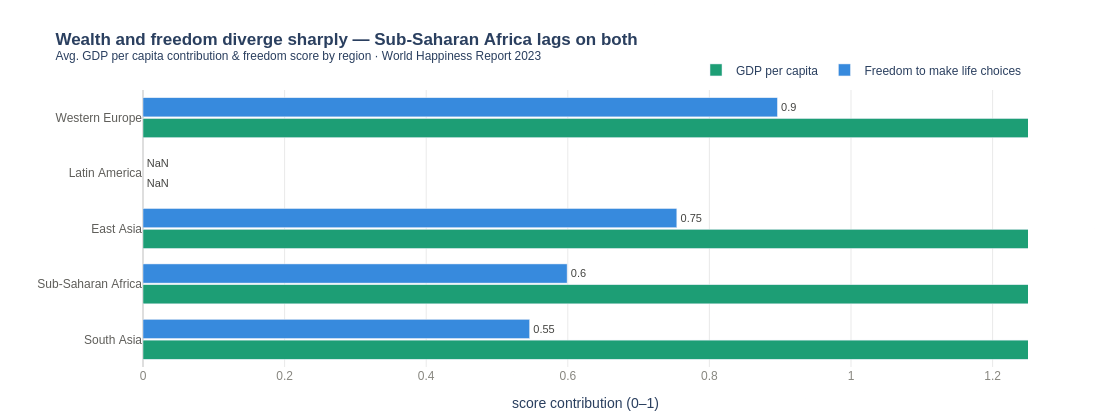

In [7]:
# Task 3: Grouped bar chart — GDP vs Freedom across 5 regions (horizontal)
# -------------------------------------------------------------------------

regions_5 = ['Western Europe', 'Latin America', 'East Asia',
             'Sub-Saharan Africa', 'South Asia']

subset = (df[df['Region'].isin(regions_5)]
          .groupby('Region')[['GDP', 'Freedom']]
          .mean()
          .reindex(regions_5)
          .reset_index())

fig = go.Figure()

factor_styles = {
    'GDP':     {'color': '#1D9E75', 'label': 'GDP per capita'},
    'Freedom': {'color': '#378ADD', 'label': 'Freedom to make life choices'},
}

for col, style in factor_styles.items():
    fig.add_trace(go.Bar(
        x=subset[col].round(3),
        y=subset['Region'],
        orientation='h',
        name=style['label'],
        marker_color=style['color'],
        text=subset[col].round(2),
        textposition='outside',
        textfont=dict(size=11, color='#444441'),
    ))

fig.update_layout(
    title=(
        '<b>Wealth and freedom diverge sharply — Sub-Saharan Africa lags on both</b><br>'
        '<sup>Avg. GDP per capita contribution & freedom score by region · World Happiness Report 2023</sup>'
    ),
    barmode='group',
    bargap=0.25,
    bargroupgap=0.08,
    xaxis=dict(
        title='score contribution (0–1)',
        range=[0, 1.25],
        showgrid=True,
        gridcolor='rgba(200,200,200,0.4)',
        zeroline=True,
        zerolinecolor='rgba(200,200,200,0.6)',
        tickfont=dict(size=12, color='#888780'),
    ),
    yaxis=dict(
        title='',
        tickfont=dict(size=12, color='#5F5E5A'),
        showgrid=False,
        categoryorder='array',
        categoryarray=regions_5[::-1],  # South Asia at bottom, Western Europe at top
    ),
    legend=dict(
        orientation='h',
        yanchor='bottom',
        y=1.02,
        xanchor='right',
        x=1,
        font=dict(size=12),
    ),
    plot_bgcolor='white',
    paper_bgcolor='white',
    height=420,
    margin=dict(l=20, r=80, t=90, b=40),
)

fig.show()